In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
DATASET_DIR = r"C:\Users\User\Documents\study\Deep Learning\dataset"
CSV_PATH = os.path.join(DATASET_DIR, "train.csv")
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = os.path.join(DATASET_DIR, "best_model.pth")

In [5]:
# df = pd.read_csv("dataset/train.csv")
# print(df.head())


# for _, row in tqdm(df.iterrows(), total=len(df)):
#     try:
#         img = Image.open(os.path.join("dataset", row["file_name"]))
#         img.verify()
#     except Exception as e:
#         print(f"Corrupted: {row['file_name']} -> {e}")

df = pd.read_csv(CSV_PATH)

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

In [7]:
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [8]:
class CustomImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df.loc[idx, "file_name"])
        label = int(self.df.loc[idx, "label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
train_dataset = CustomImageDataset(train_df, DATASET_DIR, transform=train_transform)
val_dataset = CustomImageDataset(val_df, DATASET_DIR, transform=val_test_transform)
test_dataset = CustomImageDataset(test_df, DATASET_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [10]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # 2 classes (0 and 1)
model = model.to(DEVICE)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)



In [10]:
print(f"Device: {DEVICE}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of train batches: {len(train_loader)}")

# Test loading one batch
print("\n🔍 Testing data loading...")
try:
    images, labels = next(iter(train_loader))
    print(f"✓ Batch loaded successfully: {images.shape}, {labels.shape}")
    print(f"✓ Moving to device...")
    images = images.to(DEVICE)
    print(f"✓ Success! Ready to train.\n")
except Exception as e:
    print(f"✗ Error during data loading: {e}")
    import traceback
    traceback.print_exc()
    print("\n⚠️ Check if image paths are correct:")
    for i in range(min(3, len(train_df))):
        path = os.path.join(DATASET_DIR, train_df.iloc[i]["file_name"])
        print(f"  {path} -> Exists: {os.path.exists(path)}")
    exit()

best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels in train_pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        train_pbar.set_postfix(loss=loss.item())

    train_acc = correct / total

    # ==== VALIDATION ====
    model.eval()
    val_correct, val_total = 0, 0
    val_loss = 0.0

    val_pbar = tqdm(val_loader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            val_pbar.set_postfix(loss=loss.item())

    val_acc = val_correct / val_total
    print(f"✅ Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'train_acc': train_acc,
        }, MODEL_SAVE_PATH)
        print(f"💾 Model saved! New best validation accuracy: {val_acc:.4f}")


Device: cuda
Train dataset size: 55965
Val dataset size: 11992
Test dataset size: 11993
Number of train batches: 1749

🔍 Testing data loading...
✓ Batch loaded successfully: torch.Size([32, 3, 224, 224]), torch.Size([32])
✓ Moving to device...
✓ Success! Ready to train.


Epoch 1/5


✅ Epoch [1/5] | Train Loss: 0.0546 | Train Acc: 0.9794 | Val Acc: 0.9946
💾 Model saved! New best validation accuracy: 0.9946

Epoch 2/5


✅ Epoch [2/5] | Train Loss: 0.0219 | Train Acc: 0.9923 | Val Acc: 0.9932

Epoch 3/5


✅ Epoch [3/5] | Train Loss: 0.0166 | Train Acc: 0.9941 | Val Acc: 0.9012

Epoch 4/5


✅ Epoch [4/5] | Train Loss: 0.0132 | Train Acc: 0.9954 | Val Acc: 0.9958
💾 Model saved! New best validation accuracy: 0.9958

Epoch 5/5


✅ Epoch [5/5] | Train Loss: 0.0122 | Train Acc: 0.9955 | Val Acc: 0.9892


In [12]:
print(f"\n📂 Loading best model from {MODEL_SAVE_PATH}")
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded model from epoch {checkpoint['epoch']+1} with val_acc: {checkpoint['val_acc']:.4f}")


📂 Loading best model from C:\Users\User\Documents\study\Deep Learning\dataset\best_model.pth


C:\Users\User\AppData\Local\Temp\ipykernel_1476\2267759354.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_SAVE_PATH)


✓ Loaded model from epoch 4 with val_acc: 0.9958



GENERATING EVALUATION METRICS

🎯 Final Test Accuracy: 0.9957

CONFUSION MATRIX
[[5986   11]
 [  41 5955]]


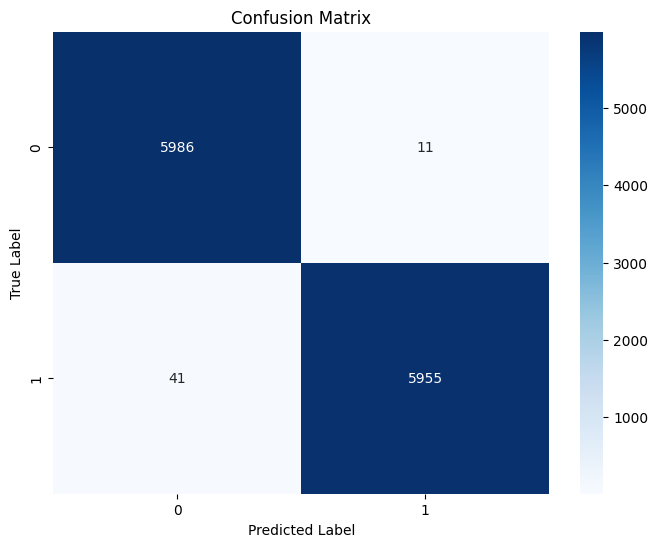

✓ Confusion matrix saved to C:\Users\User\Documents\study\Deep Learning\dataset/confusion_matrix.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00      5997
     Class 1       1.00      0.99      1.00      5996

    accuracy                           1.00     11993
   macro avg       1.00      1.00      1.00     11993
weighted avg       1.00      1.00      1.00     11993

✓ Classification report saved to C:\Users\User\Documents\study\Deep Learning\dataset/classification_report.txt

ROC AUC SCORE
ROC AUC Score: 0.9999


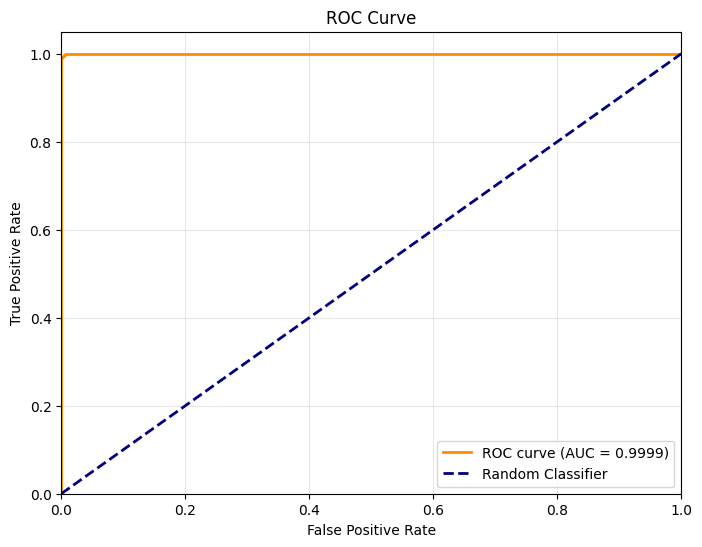

✓ ROC curve saved to C:\Users\User\Documents\study\Deep Learning\dataset/roc_curve.png

✅ Best model saved at: C:\Users\User\Documents\study\Deep Learning\dataset\best_model.pth
✅ All evaluation metrics generated successfully!


In [13]:
# ========== FINAL TEST EVALUATION WITH METRICS ==========
print("\n" + "="*50)
print("GENERATING EVALUATION METRICS")
print("="*50)

# Collect predictions
all_labels = []
all_preds = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Calculate test accuracy
test_accuracy = (all_preds == all_labels).sum() / len(all_labels)
print(f"\n🎯 Final Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(all_labels, all_preds)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(DATASET_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Confusion matrix saved to {DATASET_DIR}/confusion_matrix.png")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
report = classification_report(all_labels, all_preds, target_names=['Class 0', 'Class 1'])
print(report)

with open(os.path.join(DATASET_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)
print(f"✓ Classification report saved to {DATASET_DIR}/classification_report.txt")

# ROC AUC
print("\n" + "="*50)
print("ROC AUC SCORE")
print("="*50)
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(DATASET_DIR, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ ROC curve saved to {DATASET_DIR}/roc_curve.png")

print(f"\n✅ Best model saved at: {MODEL_SAVE_PATH}")
print("✅ All evaluation metrics generated successfully!")

In [13]:
MODEL_SAVE_PATH = r"C:\Users\User\Documents\study\Deep Learning\dataset\best_model.pth"

if os.path.exists(MODEL_SAVE_PATH):
    file_size = os.path.getsize(MODEL_SAVE_PATH) / (1024 * 1024)  # Size in MB
    print(f"✅ Model file exists!")
    print(f"📁 Location: {MODEL_SAVE_PATH}")
    print(f"📊 File size: {file_size:.2f} MB")
else:
    print(f"❌ Model file not found at {MODEL_SAVE_PATH}")

✅ Model file exists!
📁 Location: C:\Users\User\Documents\study\Deep Learning\dataset\best_model.pth
📊 File size: 128.04 MB
